In [1]:
import pandas as pd
import numpy as np
from PIL import Image

In [ ]:
def gaussian_kernel(size, sigma): #size is the size of the kernel, sigma is the standard deviation
    x = np.linspace(- (size // 2), size // 2, size) # create a 1D array of size 'size' with values from -size//2 to size//2
    x /= np.sqrt(2)*sigma # normalize the values by dividing by sqrt(2)*sigma
    x2 = x**2 # square the values
    kernel = np.exp(- x2[:, None] - x2[None, :]) # create a 2D kernel by applying the Gaussian function to the squared values
    #x2[:, None] creates a column vector.
    #x2[None, :] creates a row vector. -->x^2 + y^2
    return kernel / kernel.sum() # normalize the kernel by dividing by the sum of all elements


In [ ]:
size = 7
sigma = size / 6 # standard deviation is usually set to size/6 for a Gaussian kernel
gauss = gaussian_kernel(size,sigma)
gauss #displays kernel

array([[0.00015776, 0.0009901 , 0.00298049, 0.00430352, 0.00298049,
        0.0009901 , 0.00015776],
       [0.0009901 , 0.00621385, 0.01870557, 0.02700894, 0.01870557,
        0.00621385, 0.0009901 ],
       [0.00298049, 0.01870557, 0.05630943, 0.08130511, 0.05630943,
        0.01870557, 0.00298049],
       [0.00430352, 0.02700894, 0.08130511, 0.11739636, 0.08130511,
        0.02700894, 0.00430352],
       [0.00298049, 0.01870557, 0.05630943, 0.08130511, 0.05630943,
        0.01870557, 0.00298049],
       [0.0009901 , 0.00621385, 0.01870557, 0.02700894, 0.01870557,
        0.00621385, 0.0009901 ],
       [0.00015776, 0.0009901 , 0.00298049, 0.00430352, 0.00298049,
        0.0009901 , 0.00015776]])

In [ ]:
dx = dy = size // 2 #for size=7, dx=dy=3, (3,3) is the center of the kernel
gaussMap = {} # create a dictionary to store the gaussian weights for each (i,j) position in the kernel
p = np.linspace(- (size // 2), size // 2, size).astype(int) # create a 1D array of size 'size' with integer values from -size//2 to size//2, which will be used to index the kernel
for i in p: # iterate over the range of the kernel size, which will be used to index the kernel
    for j in p: # iterate over the range of the kernel size, which will be used to index the kernel
        gaussMap[(i,j)] = gauss[dx + i][dx + j] # store the gaussian weight for the (i,j) position in the kernel in the gaussMap dictionary, where dx and dy are used to shift the index to the center of the kernel

In [ ]:
from collections import defaultdict # automatically return 0 for missing keys
def pointCalc(i,j,mat,gaussMap): #compute gaussian filtered value for the pixel at (i,j) in the image matrix 'mat' using the gaussian weights in 'gaussMap'
    p = np.linspace(- (size // 2), size // 2, size).astype(int)
    pixMap = defaultdict(int) #store neighboring pixel value,default value 0
    for dx in p: #moves vertically
        if i + dx >= 0 and i + dx < len(mat): #ensure row inside img
            for dy in p:
                if j + dy >= 0 and j + dy < len(mat[0]):
                    pixMap[(dx,dy)] = mat[i+dx][j+dy] #store pixel value for the (dx,dy) position in the pixMap dictionary, where dx and dy are used to shift the index to the neighboring pixel
    res = 0 #store computed gaussian filter value
    for dx in p:
        for dy in p:
            res += gaussMap[(dx,dy)] * pixMap[(dx,dy)] #gaussian weight * pixel value
    return res

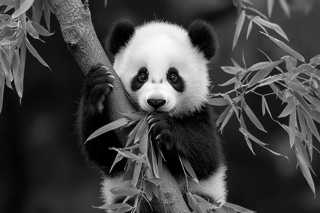

In [6]:
img = Image.open('images/panda.jpeg').convert('L').resize((640 // 2,426 // 2))
img

In [7]:
imgMat = np.array(img)
imgMat

array([[107, 104, 104, ...,  67,  69,  70],
       [111, 112, 105, ...,  66,  68,  69],
       [111, 106, 106, ...,  65,  67,  67],
       ...,
       [ 16,  16,  15, ...,  31,  31,  31],
       [ 16,  16,  15, ...,  28,  28,  28],
       [ 16,  16,  15, ...,  27,  27,  27]], shape=(213, 320), dtype=uint8)

In [9]:
gausImg = imgMat.copy()
for i in range(len(imgMat)):
    for j in range(len(imgMat[0])):
        gausImg[i][j] = pointCalc(i,j,imgMat,gaussMap)
        print(gausImg[i][j],imgMat[i][j])

48 107
65 104
70 104
70 106
70 106
70 105
70 105
71 107
72 108
73 110
72 110
72 111
73 111
73 111
72 121
68 103
63 95
58 83
56 80
59 82
66 92
74 122
79 121
84 115
93 117
102 155
109 175
112 169
115 168
117 179
118 181
115 172
105 173
85 164
62 86
45 57
38 55
36 52
35 54
33 53
30 43
29 39
31 46
33 54
35 50
37 56
38 63
37 53
36 49
37 50
41 76
46 58
51 76
54 78
58 95
60 77
64 95
67 111
69 120
68 84
70 105
71 152
69 88
67 102
66 91
67 101
68 87
72 103
79 151
84 129
84 120
85 127
89 153
94 153
97 151
99 140
101 169
100 153
97 123
91 152
77 127
52 47
31 26
26 23
35 33
50 87
61 133
57 107
39 42
23 20
15 22
14 21
14 22
14 23
15 22
15 23
16 24
16 26
17 26
17 26
18 27
18 28
19 26
25 26
37 52
47 96
45 83
34 41
24 30
20 30
19 31
19 29
19 29
19 29
19 29
19 28
18 28
18 28
18 28
17 26
17 25
16 24
16 24
15 24
15 24
15 24
15 24
15 23
15 23
15 23
15 23
14 22
14 22
14 22
14 22
14 20
14 21
14 22
15 24
15 23
15 23
15 23
15 23
14 22
14 22
14 22
14 22
15 23
15 23
15 23
15 23
15 23
15 23
15 23
15 23
15 23
15 

In [10]:
final = Image.fromarray(gausImg)

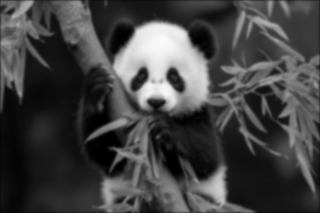

In [11]:
final

In [12]:
final.save('images/gauss.jpeg')